In [1]:
# Core data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Preprocessing & model selection
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Handling class imbalance
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay
)

# Feature importance
from sklearn.inspection import permutation_importance

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Load the dataset
df = pd.read_csv('C:\\Users\\elhay\\OneDrive\\Desktop\\Customer_Churn\\Telco-Customer-Churn.csv')

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn names:\n{df.columns.tolist()}")
df.head()


Dataset shape: 7,043 rows × 21 columns

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Data types audit
print(df.dtypes)

# Convert TotalCharges to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Null values after coercion: {df['TotalCharges'].isnull().sum()}")
print("\nRows where TotalCharges is null:")
print(df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']])

# Missing values audit
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct})
print(missing_df[missing_df['Count'] > 0])

# Summary statistics for numeric columns
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2)


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
Null values after coercion: 11

Rows where TotalCharges is null:
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35    

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7032.00
mean,32.37,64.76,2283.30
std,24.56,30.09,2266.77
min,0.00,18.25,18.80
25%,9.00,35.50,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.85,3794.74
max,72.00,118.75,8684.80


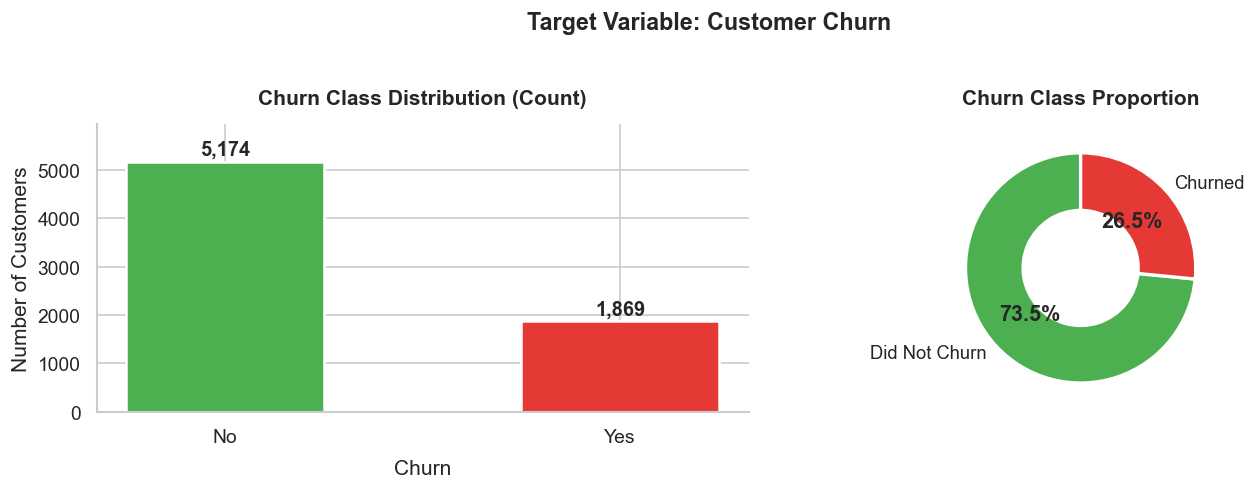


Class distribution:
  No  (Retained): 5,174  (73.5%)
  Yes (Churned):  1,869  (26.5%)
  Imbalance ratio: 2.77:1


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Count bar chart with annotations
churn_counts = df['Churn'].value_counts()
colors = ['#4CAF50', '#E53935']
bars = axes[0].bar(churn_counts.index, churn_counts.values, color=colors,
                   edgecolor='white', linewidth=1.5, width=0.5)

for bar, count in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
                 f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)

axes[0].set_title('Churn Class Distribution (Count)', fontweight='bold', pad=12)
axes[0].set_xlabel('Churn', labelpad=8)
axes[0].set_ylabel('Number of Customers')
axes[0].set_ylim(0, churn_counts.max() * 1.15)

# Right: Proportion donut chart with annotations
churn_pct = churn_counts / len(df) * 100
wedges, texts, autotexts = axes[1].pie(
    churn_pct.values,
    labels=['Did Not Churn', 'Churned'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2),
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(13)

axes[1].set_title('Churn Class Proportion', fontweight='bold', pad=12)

plt.suptitle('Target Variable: Customer Churn', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_01_class_balance.png', bbox_inches='tight')
plt.show()

print(f"\nClass distribution:")
print(f"  No  (Retained): {churn_counts['No']:,}  ({churn_counts['No']/len(df)*100:.1f}%)")
print(f"  Yes (Churned):  {churn_counts['Yes']:,}  ({churn_counts['Yes']/len(df)*100:.1f}%)")
print(f"  Imbalance ratio: {churn_counts['No']/churn_counts['Yes']:.2f}:1")


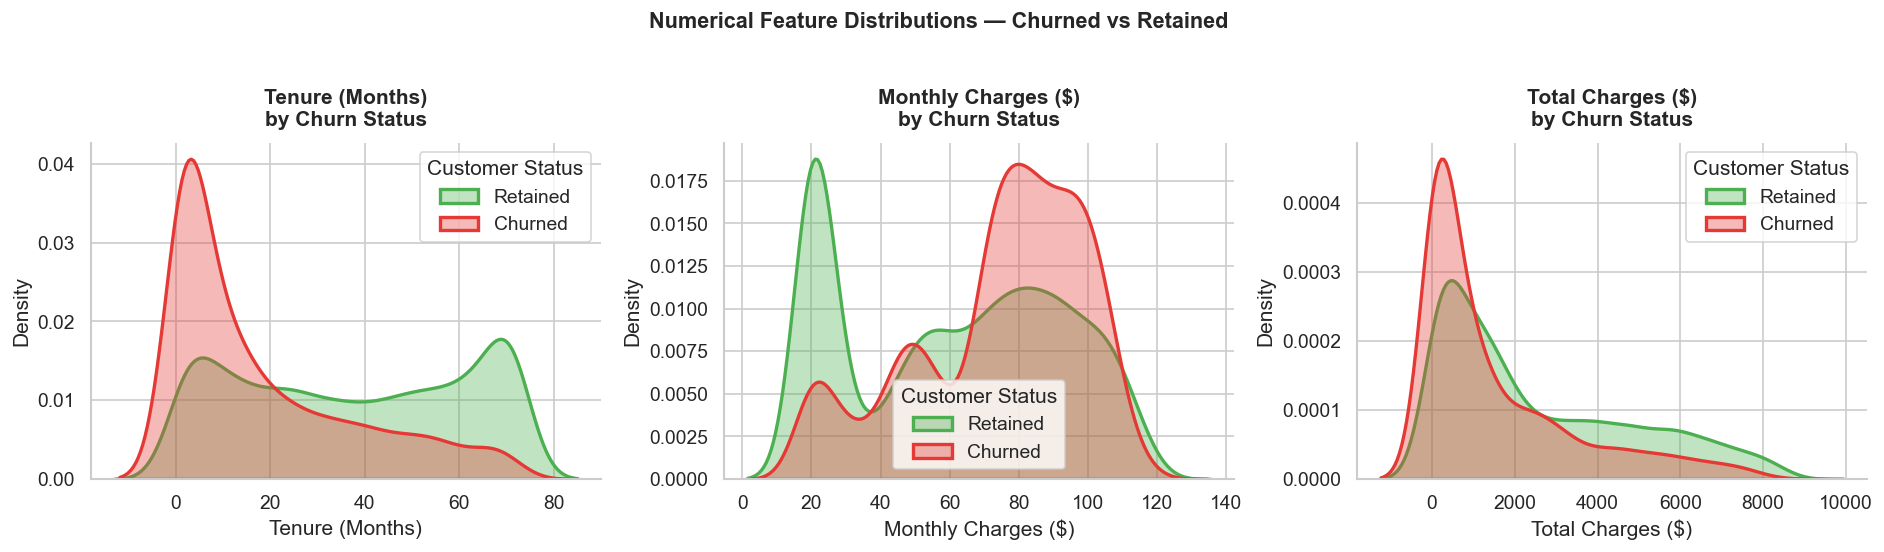

In [5]:
# Numerical feature distributions
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
col_labels = {
    'tenure': 'Tenure (Months)',
    'MonthlyCharges': 'Monthly Charges ($)',
    'TotalCharges': 'Total Charges ($)'
}

# Create KDE plots for each numerical feature, split by churn status
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, col in zip(axes, numerical_cols):
    for churn_val, color, label in [('No', '#4CAF50', 'Retained'), ('Yes', '#E53935', 'Churned')]:
        subset = df[df['Churn'] == churn_val][col].dropna()
        sns.kdeplot(subset, ax=ax, color=color, label=label,
                    fill=True, alpha=0.35, linewidth=2)

    ax.set_title(f'{col_labels[col]}\nby Churn Status', fontweight='bold', pad=10)
    ax.set_xlabel(col_labels[col])
    ax.set_ylabel('Density')
    ax.legend(title='Customer Status', framealpha=0.8)

plt.suptitle('Numerical Feature Distributions — Churned vs Retained',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_02_numerical_distributions.png', bbox_inches='tight')
plt.show()


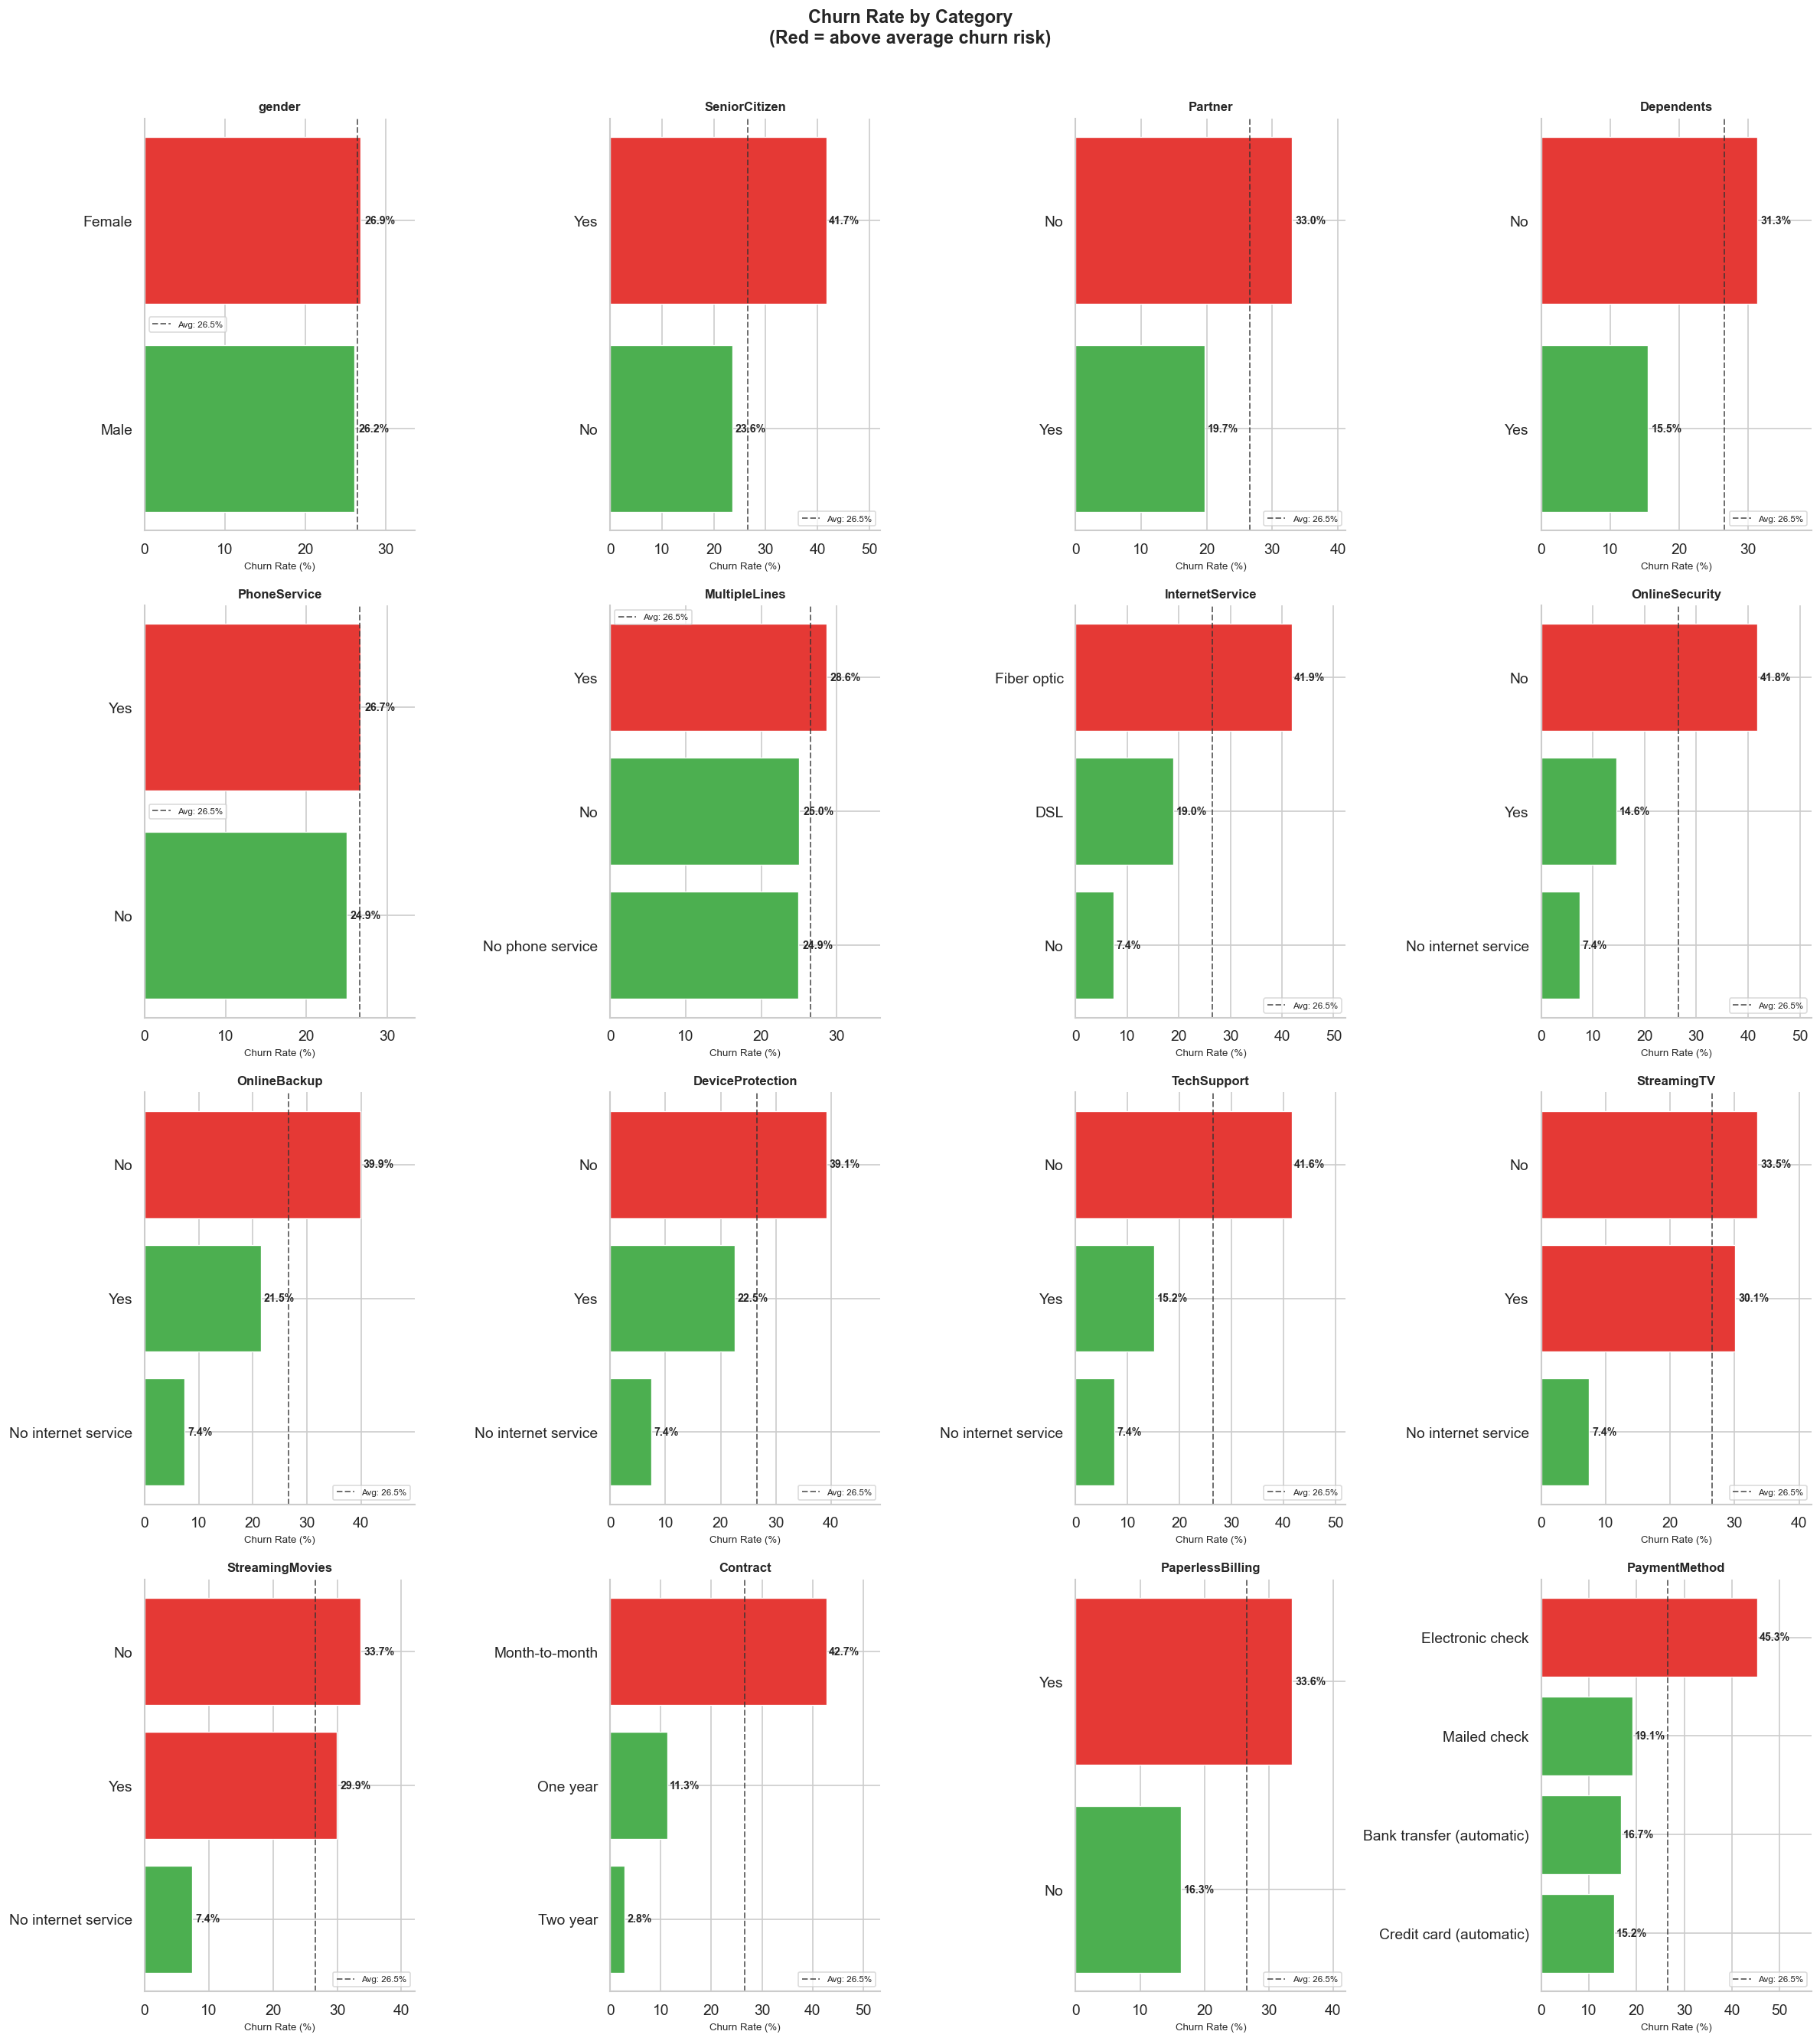

In [6]:
# Categorical columns to analyse (excluding customerID and target)
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

# Convert SeniorCitizen from 0/1 to No/Yes for readability
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# Calculate overall churn rate for reference
overall_churn_rate = (df['Churn'] == 'Yes').mean() * 100

# Categorical feature churn rates
fig, axes = plt.subplots(4, 4, figsize=(20, 22))
axes = axes.flatten()

for idx, col in enumerate(cat_cols):
    ax = axes[idx]
    # Churn rate per category
    churn_rates = (
        df.groupby(col)['Churn']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .sort_values(ascending=True)
        .reset_index()
    )
    churn_rates.columns = [col, 'churn_rate']

    # Colour bars above/below overall average
    bar_colors = ['#E53935' if r > overall_churn_rate else '#4CAF50'
                  for r in churn_rates['churn_rate']]

    bars = ax.barh(churn_rates[col], churn_rates['churn_rate'],
                   color=bar_colors, edgecolor='white', linewidth=0.8)

    # Add value labels
    for bar, val in zip(bars, churn_rates['churn_rate']):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=8.5, fontweight='bold')

    # Overall average line
    ax.axvline(overall_churn_rate, color='#333', linestyle='--',
               linewidth=1.2, alpha=0.7, label=f'Avg: {overall_churn_rate:.1f}%')

    ax.set_title(col, fontweight='bold', fontsize=10, pad=6)
    ax.set_xlabel('Churn Rate (%)', fontsize=8)
    ax.set_xlim(0, max(churn_rates['churn_rate']) * 1.25)
    ax.legend(fontsize=7, framealpha=0.7)

# Hide any unused subplots
for idx in range(len(cat_cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Churn Rate by Category\n(Red = above average churn risk)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_03_categorical_churn_rates.png', bbox_inches='tight')
plt.show()


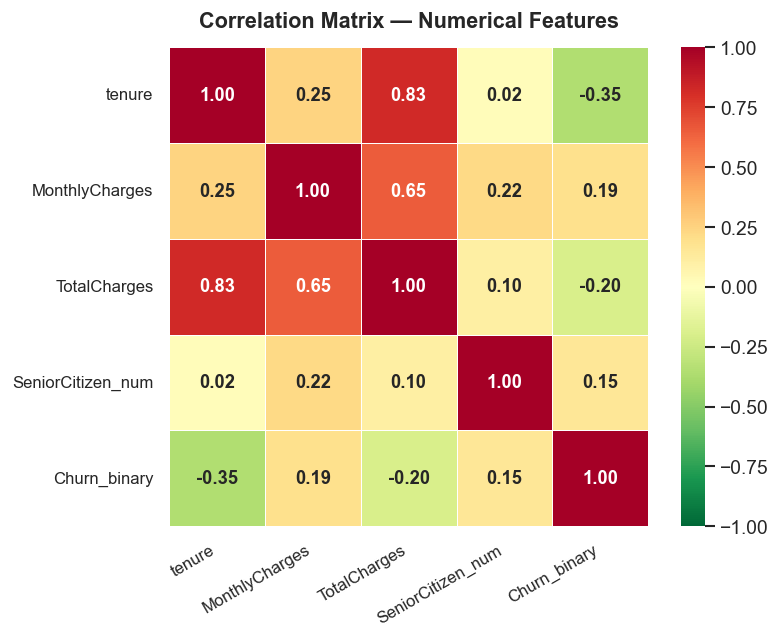

In [7]:
# Create a numeric version of key columns for correlation analysis
df_corr = df.copy()
df_corr['Churn_binary'] = (df_corr['Churn'] == 'Yes').astype(int)
df_corr['SeniorCitizen_num'] = (df_corr['SeniorCitizen'] == 'Yes').astype(int)

# Select numerical columns
num_cols_corr = ['tenure', 'MonthlyCharges', 'TotalCharges',
                 'SeniorCitizen_num', 'Churn_binary']

corr_matrix = df_corr[num_cols_corr].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # upper triangle mask

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    ax=ax,
    annot_kws={'size': 11, 'weight': 'bold'}
)

ax.set_title('Correlation Matrix — Numerical Features',
             fontweight='bold', fontsize=13, pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('plot_04_correlation_heatmap.png', bbox_inches='tight')
plt.show()


In [8]:
# Drop customerID as it's a unique identifier and not useful for modeling
df_clean = df.drop(columns=['customerID'])
print("After dropping customerID:", df_clean.shape)

# Drop rows with null TotalCharges
df_clean = df_clean.dropna(subset=['TotalCharges'])
print("After dropping null TotalCharges:", df_clean.shape)

# Recode 'No internet service' / 'No phone service' → 'No' 
service_replace_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in service_replace_cols:
    df_clean[col] = df_clean[col].replace('No internet service', 'No')
df_clean['MultipleLines'] = df_clean['MultipleLines'].replace('No phone service', 'No')

# Encode binary Yes/No columns 
binary_cols = [
    'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'MultipleLines'
]
df_clean['gender'] = df_clean['gender'].map({'Male': 1, 'Female': 0})
df_clean['SeniorCitizen'] = df_clean['SeniorCitizen'].map({'Yes': 1, 'No': 0})

le = LabelEncoder()
for col in binary_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

# One-hot encode multi-class categorical columns
multi_cat_cols = ['InternetService', 'Contract', 'PaymentMethod']
df_clean = pd.get_dummies(df_clean, columns=multi_cat_cols, drop_first=False)

# Drop one dummy per group to avoid the dummy variable trap
drop_dummies = [
    'InternetService_DSL',
    'Contract_Month-to-month',
    'PaymentMethod_Bank transfer (automatic)'
]
df_clean = df_clean.drop(columns=[c for c in drop_dummies if c in df_clean.columns])

# Encode target variable
df_clean['Churn'] = (df_clean['Churn'] == 'Yes').astype(int)

# Verify
print("Final dataset shape:", df_clean.shape)
print("All dtypes numeric:", all(df_clean.dtypes != object))
print("Columns:", df_clean.columns.tolist())
print("Target distribution:")
print(df_clean['Churn'].value_counts())


After dropping customerID: (7043, 20)
After dropping null TotalCharges: (7032, 20)
Final dataset shape: (7032, 24)
All dtypes numeric: True
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
Target distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [9]:
# Feature engineering
# AvgMonthlySpend: Monthly charges relative to tenure
# Avoids divide-by-zero for tenure=0 customers by replacing with MonthlyCharges
df_clean['AvgMonthlySpend'] = df_clean.apply(
    lambda row: row['MonthlyCharges'] if row['tenure'] == 0
                else row['TotalCharges'] / row['tenure'],
    axis=1
)

# ServiceCount: how many optional services does a customer subscribe to?
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
df_clean['ServiceCount'] = df_clean[service_cols].sum(axis=1)

print("New features added: AvgMonthlySpend, ServiceCount")
print(f"Dataset shape after feature engineering: {df_clean.shape}")

# Train/test split 
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y          # ← crucial for imbalanced data
)

print(f"\nTraining set:  {X_train.shape[0]:,} rows  |  Churn rate: {y_train.mean()*100:.1f}%")
print(f"Test set:      {X_test.shape[0]:,} rows  |  Churn rate: {y_test.mean()*100:.1f}%")
print(f"\nFeatures used: {X.shape[1]}")
print(X.columns.tolist())


New features added: AvgMonthlySpend, ServiceCount
Dataset shape after feature engineering: (7032, 26)

Training set:  5,625 rows  |  Churn rate: 26.6%
Test set:      1,407 rows  |  Churn rate: 26.6%

Features used: 25
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'AvgMonthlySpend', 'ServiceCount']


In [10]:
# Apply SMOTE to training data only
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Training set — before SMOTE:")
print(f"  Retained (0): {(y_train==0).sum():,}  |  Churned (1): {(y_train==1).sum():,}")
print(f"\nTraining set — after SMOTE:")
print(f"  Retained (0): {(y_train_sm==0).sum():,}  |  Churned (1): {(y_train_sm==1).sum():,}")
print(f"  Total rows: {len(y_train_sm):,}")
print(f"\nTest set — unchanged (real-world distribution):")
print(f"  Retained (0): {(y_test==0).sum():,}  |  Churned (1): {(y_test==1).sum():,}")

# Feature scaling (for Logistic Regression) 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)   # fit on SMOTE-augmented train
X_test_scaled  = scaler.transform(X_test)            # transform test with same scaler

print(f"\nScaling applied. Train mean ≈ {X_train_scaled.mean():.3f}, std ≈ {X_train_scaled.std():.3f}")


Training set — before SMOTE:
  Retained (0): 4,130  |  Churned (1): 1,495

Training set — after SMOTE:
  Retained (0): 4,130  |  Churned (1): 4,130
  Total rows: 8,260

Test set — unchanged (real-world distribution):
  Retained (0): 1,033  |  Churned (1): 374

Scaling applied. Train mean ≈ -0.000, std ≈ 1.000


In [11]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight='balanced'      # additional safeguard
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        class_weight='balanced',
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=y_train.value_counts()[0] / y_train.value_counts()[1],
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        verbosity=0
    )
}

# Cross-validation comparison
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("5-Fold Stratified Cross-Validation Results (on SMOTE-augmented training data)")

cv_results = {}
for name, model in models.items():
    # Use scaled data for LR, raw SMOTE data for tree models
    X_cv = X_train_scaled if name == 'Logistic Regression' else X_train_sm

    roc_scores = cross_val_score(model, X_cv, y_train_sm, cv=cv,
                                  scoring='roc_auc', n_jobs=-1)
    f1_scores  = cross_val_score(model, X_cv, y_train_sm, cv=cv,
                                  scoring='f1', n_jobs=-1)

    cv_results[name] = {'roc_auc': roc_scores, 'f1': f1_scores}

    print(f"\n{name}:")
    print(f"  ROC-AUC: {roc_scores.mean():.4f} ± {roc_scores.std():.4f}")
    print(f"  F1:      {f1_scores.mean():.4f}  ± {f1_scores.std():.4f}")

print("\n Cross-validation complete.")


5-Fold Stratified Cross-Validation Results (on SMOTE-augmented training data)

Logistic Regression:
  ROC-AUC: 0.9216 ± 0.0027
  F1:      0.8316  ± 0.0047

Random Forest:
  ROC-AUC: 0.9184 ± 0.0024
  F1:      0.8417  ± 0.0051

XGBoost:
  ROC-AUC: 0.9291 ± 0.0016
  F1:      0.8450  ± 0.0057

 Cross-validation complete.


In [12]:
# Train all models and collect results
trained_models = {}
test_results   = {}

for name, model in models.items():
    X_tr = X_train_scaled if name == 'Logistic Regression' else X_train_sm
    X_te = X_test_scaled  if name == 'Logistic Regression' else X_test

    model.fit(X_tr, y_train_sm)
    trained_models[name] = model

    y_pred      = model.predict(X_te)
    y_pred_prob = model.predict_proba(X_te)[:, 1]

    roc_auc  = roc_auc_score(y_test, y_pred_prob)
    report   = classification_report(y_test, y_pred, output_dict=True)

    test_results[name] = {
        'y_pred':      y_pred,
        'y_pred_prob': y_pred_prob,
        'roc_auc':     roc_auc,
        'report':      report
    }


    print(f"  {name}")
    print(f"  ROC-AUC:  {roc_auc:.4f}")
    print(f"  {'':25s}  Precision   Recall   F1-Score   Support")
    print(f"  {'Retained (0)':25s}  {report['0']['precision']:.3f}       {report['0']['recall']:.3f}    {report['0']['f1-score']:.3f}      {report['0']['support']}")
    print(f"  {'Churned (1)':25s}  {report['1']['precision']:.3f}       {report['1']['recall']:.3f}    {report['1']['f1-score']:.3f}      {report['1']['support']}")
    print(f"  {'Accuracy':25s}  {report['accuracy']:.3f}")


  Logistic Regression
  ROC-AUC:  0.8164
                             Precision   Recall   F1-Score   Support
  Retained (0)               0.862       0.820    0.840      1033.0
  Churned (1)                0.561       0.636    0.596      374.0
  Accuracy                   0.771
  Random Forest
  ROC-AUC:  0.8174
                             Precision   Recall   F1-Score   Support
  Retained (0)               0.865       0.799    0.830      1033.0
  Churned (1)                0.541       0.655    0.593      374.0
  Accuracy                   0.760
  XGBoost
  ROC-AUC:  0.8175
                             Precision   Recall   F1-Score   Support
  Retained (0)               0.897       0.696    0.784      1033.0
  Churned (1)                0.481       0.778    0.594      374.0
  Accuracy                   0.718


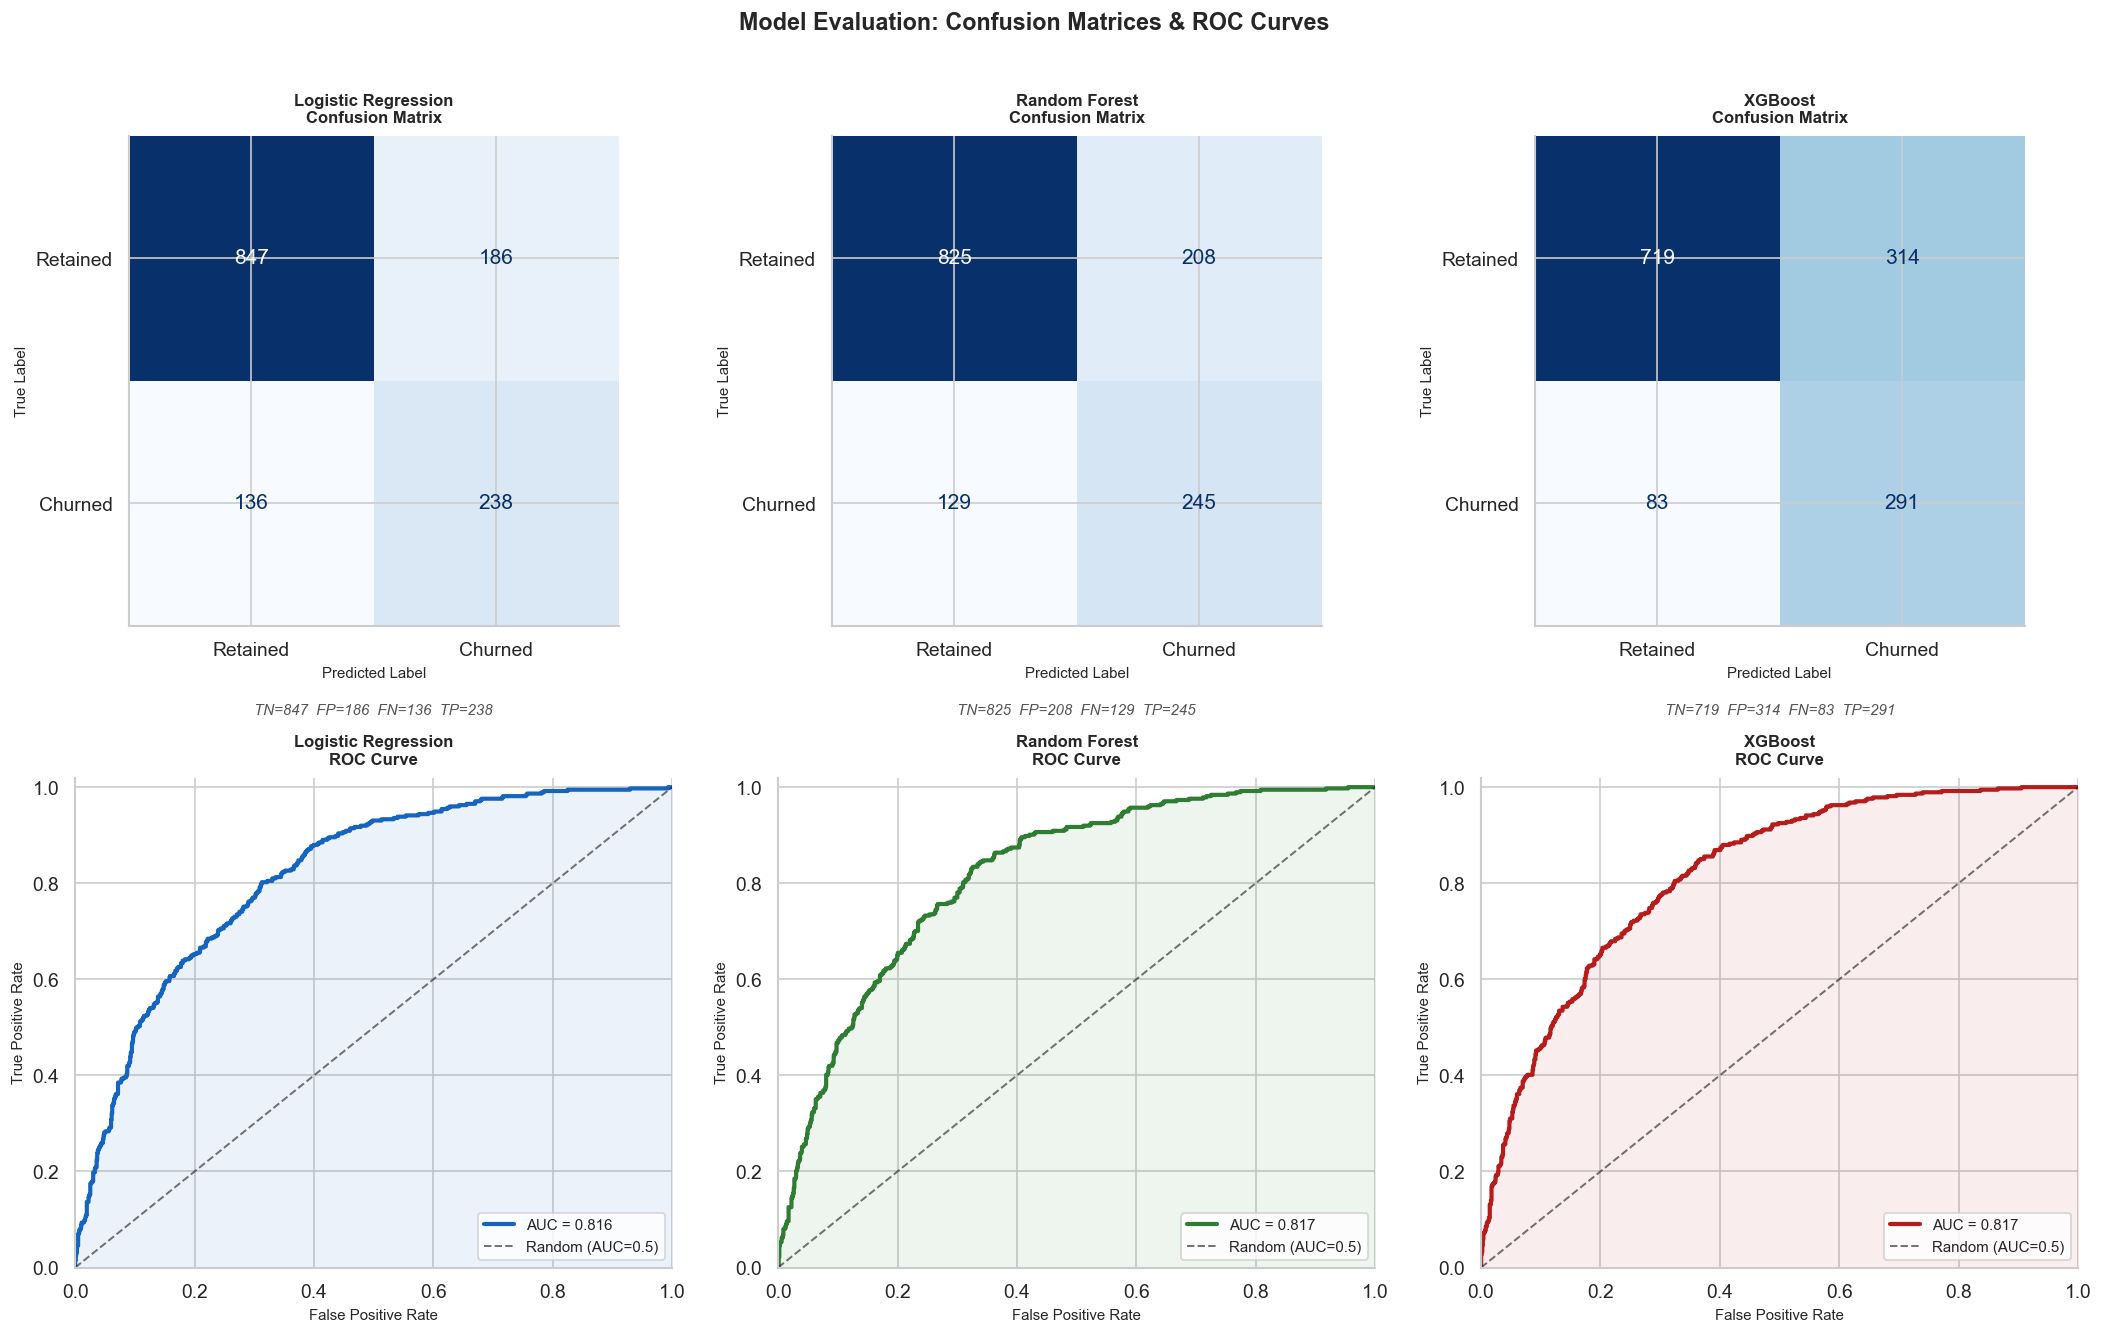

In [13]:
# Visualise confusion matrices and ROC curves for all models
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
model_names = list(trained_models.keys())
colors_roc = ['#1565C0', '#2E7D32', '#B71C1C']

for col_idx, (name, results) in enumerate(test_results.items()):

    # Confusion Matrix
    ax_cm = axes[0, col_idx]
    cm = confusion_matrix(y_test, results['y_pred'])

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Retained', 'Churned'])
    disp.plot(ax=ax_cm, colorbar=False, cmap='Blues', values_format='d')

    ax_cm.set_title(f'{name}\nConfusion Matrix', fontweight='bold', fontsize=10, pad=8)
    ax_cm.set_xlabel('Predicted Label', fontsize=9)
    ax_cm.set_ylabel('True Label', fontsize=9)

    # Annotate with FN/FP labels
    tn, fp, fn, tp = cm.ravel()
    ax_cm.text(0.5, -0.18, f'TN={tn}  FP={fp}  FN={fn}  TP={tp}',
               transform=ax_cm.transAxes, ha='center', fontsize=9,
               color='#555', style='italic')

    # ROC Curve
    ax_roc = axes[1, col_idx]
    fpr, tpr, _ = roc_curve(y_test, results['y_pred_prob'])
    auc_val = results['roc_auc']

    ax_roc.plot(fpr, tpr, color=colors_roc[col_idx],
                lw=2.5, label=f'AUC = {auc_val:.3f}')
    ax_roc.fill_between(fpr, tpr, alpha=0.08, color=colors_roc[col_idx])
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.6, label='Random (AUC=0.5)')

    ax_roc.set_xlim([0, 1])
    ax_roc.set_ylim([0, 1.02])
    ax_roc.set_xlabel('False Positive Rate', fontsize=9)
    ax_roc.set_ylabel('True Positive Rate', fontsize=9)
    ax_roc.set_title(f'{name}\nROC Curve', fontweight='bold', fontsize=10, pad=8)
    ax_roc.legend(loc='lower right', fontsize=9, framealpha=0.8)

plt.suptitle('Model Evaluation: Confusion Matrices & ROC Curves',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_05_confusion_roc.png', bbox_inches='tight')
plt.show()


Best model by ROC-AUC: XGBoost


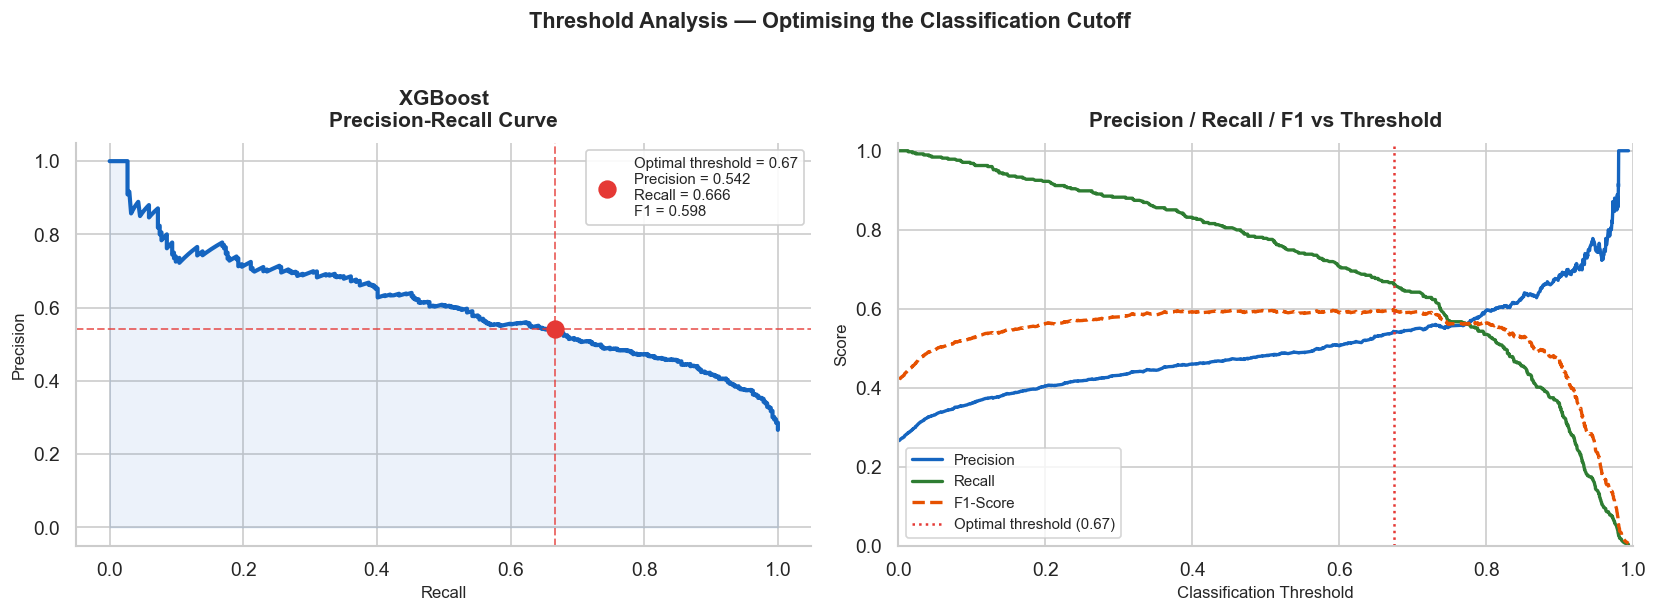


 Recommended optimal threshold: 0.674
   At this threshold:
   Precision: 0.542
   Recall:    0.666
   F1:        0.598


In [14]:
# Use XGBoost as best model (adjust if Random Forest wins in CV)
best_model_name = max(test_results, key=lambda k: test_results[k]['roc_auc'])
best_results    = test_results[best_model_name]
print(f"Best model by ROC-AUC: {best_model_name}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision-Recall Curve
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(
    y_test, best_results['y_pred_prob']
)

# Find threshold maximising F1
f1_scores_thresh = 2 * precision_vals * recall_vals / (precision_vals + recall_vals + 1e-8)
best_thresh_idx  = np.argmax(f1_scores_thresh)
best_threshold   = thresholds_pr[best_thresh_idx]

axes[0].plot(recall_vals, precision_vals, color='#1565C0', lw=2.5)
axes[0].axhline(y=precision_vals[best_thresh_idx], color='#E53935',
                linestyle='--', lw=1.2, alpha=0.7)
axes[0].axvline(x=recall_vals[best_thresh_idx], color='#E53935',
                linestyle='--', lw=1.2, alpha=0.7)
axes[0].scatter(recall_vals[best_thresh_idx], precision_vals[best_thresh_idx],
                color='#E53935', zorder=5, s=100,
                label=f'Optimal threshold = {best_threshold:.2f}\n'
                      f'Precision = {precision_vals[best_thresh_idx]:.3f}\n'
                      f'Recall = {recall_vals[best_thresh_idx]:.3f}\n'
                      f'F1 = {f1_scores_thresh[best_thresh_idx]:.3f}')
axes[0].fill_between(recall_vals, precision_vals, alpha=0.08, color='#1565C0')
axes[0].set_xlabel('Recall', fontsize=10)
axes[0].set_ylabel('Precision', fontsize=10)
axes[0].set_title(f'{best_model_name}\nPrecision-Recall Curve', fontweight='bold', pad=10)
axes[0].legend(fontsize=9, loc='upper right', framealpha=0.9)

# Precision, Recall, F1 vs Threshold
axes[1].plot(thresholds_pr, precision_vals[:-1], color='#1565C0',
             lw=2, label='Precision')
axes[1].plot(thresholds_pr, recall_vals[:-1],    color='#2E7D32',
             lw=2, label='Recall')
axes[1].plot(thresholds_pr, f1_scores_thresh[:-1], color='#E65100',
             lw=2, label='F1-Score', linestyle='--')
axes[1].axvline(x=best_threshold, color='#E53935', linestyle=':', lw=1.5,
                label=f'Optimal threshold ({best_threshold:.2f})')
axes[1].set_xlabel('Classification Threshold', fontsize=10)
axes[1].set_ylabel('Score', fontsize=10)
axes[1].set_title('Precision / Recall / F1 vs Threshold', fontweight='bold', pad=10)
axes[1].legend(fontsize=9, framealpha=0.8)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.suptitle('Threshold Analysis — Optimising the Classification Cutoff',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_06_precision_recall.png', bbox_inches='tight')
plt.show()

print(f"\n Recommended optimal threshold: {best_threshold:.3f}")
print(f"   At this threshold:")
y_pred_opt = (best_results['y_pred_prob'] >= best_threshold).astype(int)
from sklearn.metrics import f1_score, precision_score, recall_score
print(f"   Precision: {precision_score(y_test, y_pred_opt):.3f}")
print(f"   Recall:    {recall_score(y_test, y_pred_opt):.3f}")
print(f"   F1:        {f1_score(y_test, y_pred_opt):.3f}")


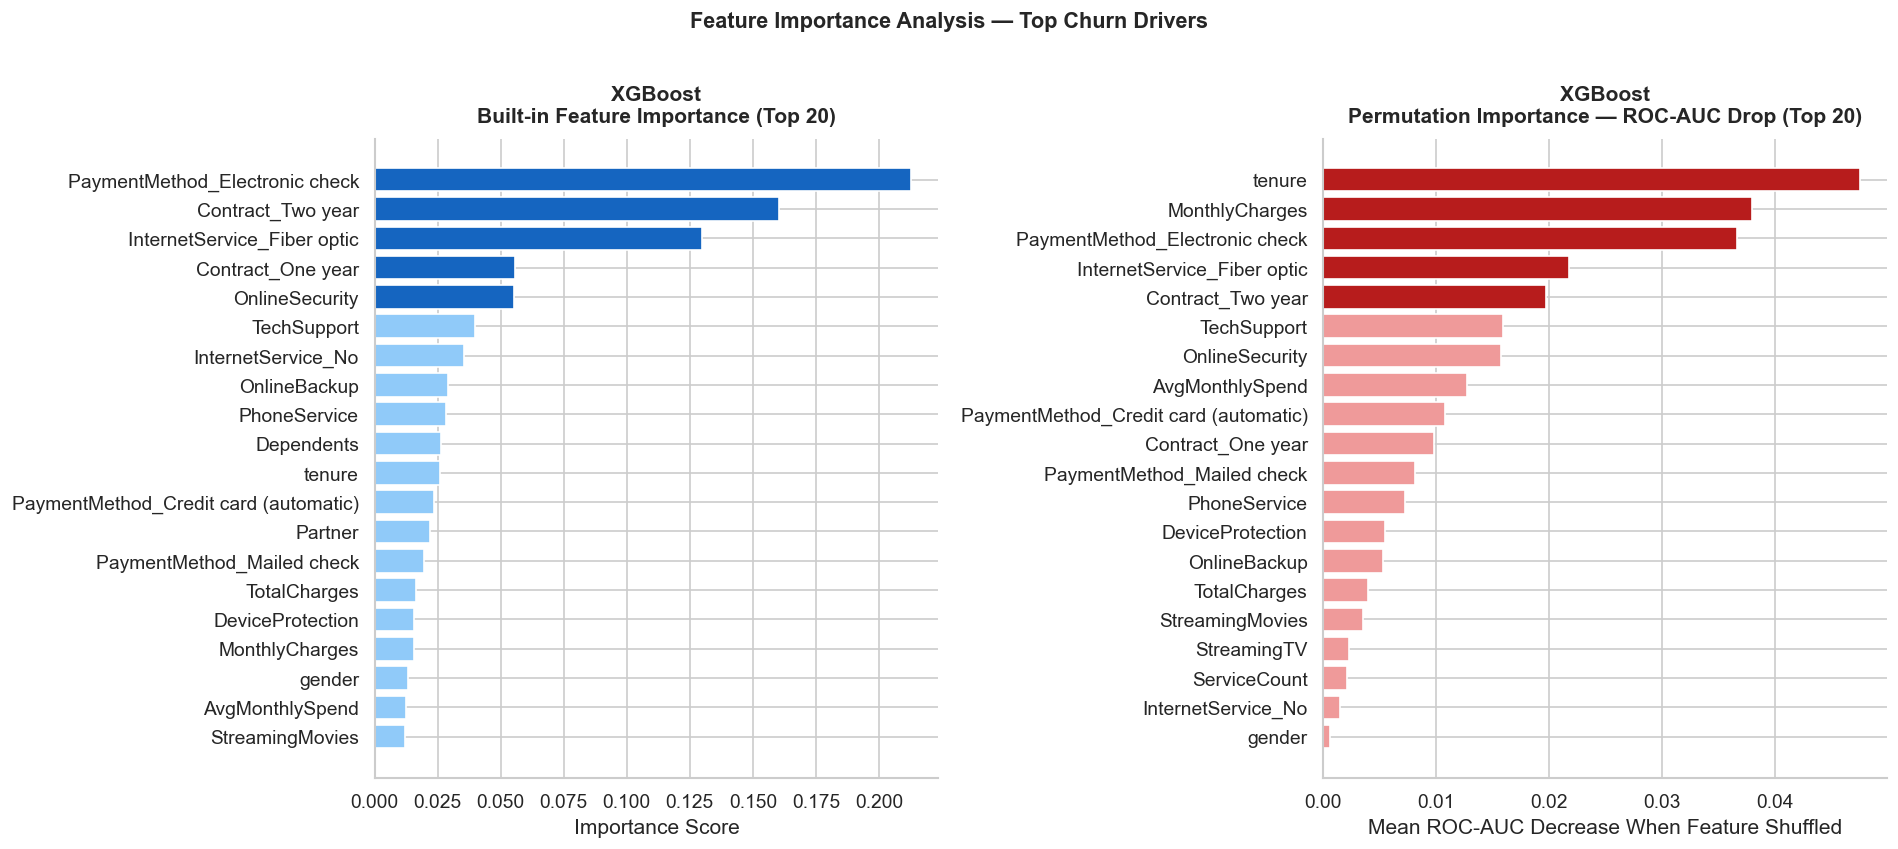


Top 10 Features (Permutation Importance):
tenure                                   0.047549
MonthlyCharges                           0.037965
PaymentMethod_Electronic check           0.036696
InternetService_Fiber optic              0.021771
Contract_Two year                        0.019729
TechSupport                              0.015913
OnlineSecurity                           0.015776
AvgMonthlySpend                          0.012755
PaymentMethod_Credit card (automatic)    0.010753
Contract_One year                        0.009787


In [15]:
# Feature Importance Analysis
best_model_obj = trained_models[best_model_name]
feature_names  = X.columns.tolist()

#Built-in feature importance (XGBoost / Random Forest) 
if hasattr(best_model_obj, 'feature_importances_'):
    importances_builtin = pd.Series(
        best_model_obj.feature_importances_, index=feature_names
    ).sort_values(ascending=False).head(20)
else:
    importances_builtin = None

# Permutation importance
X_te_use = X_test_scaled if best_model_name == 'Logistic Regression' else X_test

perm_imp = permutation_importance(
    best_model_obj, X_te_use, y_test,
    n_repeats=20, random_state=RANDOM_STATE, scoring='roc_auc', n_jobs=-1
)
importances_perm = pd.Series(
    perm_imp.importances_mean, index=feature_names
).sort_values(ascending=False).head(20)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Built-in importance
if importances_builtin is not None:
    colors_fi = ['#1565C0' if i < 5 else '#90CAF9' for i in range(len(importances_builtin))]
    axes[0].barh(importances_builtin.index[::-1],
                 importances_builtin.values[::-1],
                 color=colors_fi[::-1], edgecolor='white')
    axes[0].set_title(f'{best_model_name}\nBuilt-in Feature Importance (Top 20)',
                      fontweight='bold', pad=10)
    axes[0].set_xlabel('Importance Score')

# Permutation importance
colors_pi = ['#B71C1C' if i < 5 else '#EF9A9A' for i in range(len(importances_perm))]
axes[1].barh(importances_perm.index[::-1],
             importances_perm.values[::-1],
             color=colors_pi[::-1], edgecolor='white')
axes[1].set_title(f'{best_model_name}\nPermutation Importance — ROC-AUC Drop (Top 20)',
                  fontweight='bold', pad=10)
axes[1].set_xlabel('Mean ROC-AUC Decrease When Feature Shuffled')

plt.suptitle('Feature Importance Analysis — Top Churn Drivers',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_07_feature_importance.png', bbox_inches='tight')
plt.show()

print("\nTop 10 Features (Permutation Importance):")
print(importances_perm.head(10).to_string())


Model Comparison — Test Set Performance
                     ROC-AUC  Precision (Churn)  Recall (Churn)  F1 (Churn)  Accuracy
Model                                                                                
Logistic Regression   0.8164             0.5613          0.6364      0.5965    0.7711
Random Forest         0.8174             0.5408          0.6551      0.5925    0.7605
XGBoost               0.8175             0.4810          0.7781      0.5945    0.7178


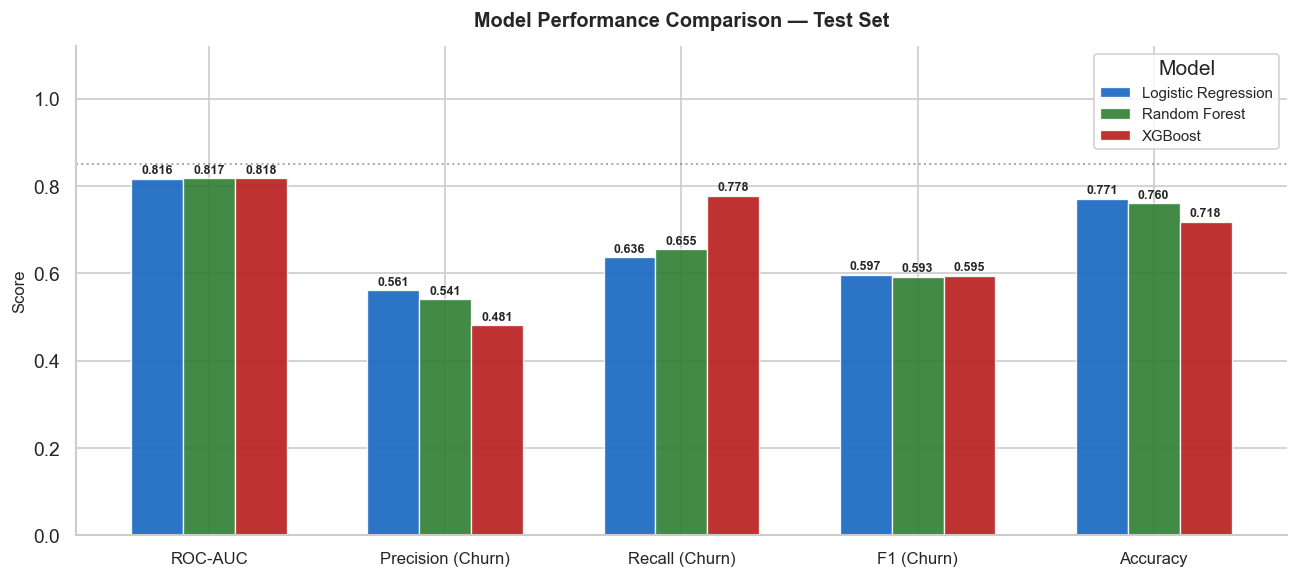

In [16]:
# Build comparison table
comparison_data = []
for name, results in test_results.items():
    rep = results['report']
    comparison_data.append({
        'Model': name,
        'ROC-AUC':       round(results['roc_auc'], 4),
        'Precision (Churn)': round(rep['1']['precision'], 4),
        'Recall (Churn)':    round(rep['1']['recall'], 4),
        'F1 (Churn)':        round(rep['1']['f1-score'], 4),
        'Accuracy':          round(rep['accuracy'], 4)
    })

comparison_df = pd.DataFrame(comparison_data).set_index('Model')
print("Model Comparison — Test Set Performance")

print(comparison_df.to_string())

# Visualise comparison
fig, ax = plt.subplots(figsize=(11, 5))

metrics  = ['ROC-AUC', 'Precision (Churn)', 'Recall (Churn)', 'F1 (Churn)', 'Accuracy']
x        = np.arange(len(metrics))
width    = 0.22
model_colors = ['#1565C0', '#2E7D32', '#B71C1C']

for i, (model_name, row) in enumerate(comparison_df.iterrows()):
    bars = ax.bar(x + i * width, [row[m] for m in metrics],
                  width=width, label=model_name, color=model_colors[i],
                  edgecolor='white', linewidth=0.8, alpha=0.9)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=10)
ax.set_title('Model Performance Comparison — Test Set', fontweight='bold', fontsize=12, pad=12)
ax.legend(title='Model', fontsize=9, framealpha=0.85, loc='upper right')
ax.axhline(y=0.85, color='#555', linestyle=':', lw=1.2, alpha=0.5,
           label='Target ROC-AUC threshold (0.85)')

plt.tight_layout()
plt.savefig('plot_08_model_comparison.png', bbox_inches='tight')
plt.show()


In [17]:
import joblib
import os

os.makedirs('model_artifacts', exist_ok=True)

# Save best model
best_model_final = trained_models[best_model_name]
joblib.dump(best_model_final, 'model_artifacts/churn_model.pkl')

# Save scaler (needed if best model is Logistic Regression)
joblib.dump(scaler, 'model_artifacts/scaler.pkl')

# Save feature names (crucial for deployment — new data must match)
joblib.dump(X.columns.tolist(), 'model_artifacts/feature_columns.pkl')

# Save the optimal threshold
joblib.dump(best_threshold, 'model_artifacts/optimal_threshold.pkl')

print(" Model artifacts saved:")
print("  model_artifacts/churn_model.pkl")
print("  model_artifacts/scaler.pkl")
print("  model_artifacts/feature_columns.pkl")
print("  model_artifacts/optimal_threshold.pkl")

#  Quick sanity check: reload and predict 
loaded_model = joblib.load('model_artifacts/churn_model.pkl')
loaded_threshold = joblib.load('model_artifacts/optimal_threshold.pkl')

X_te_final = X_test_scaled if best_model_name == 'Logistic Regression' else X_test
y_check = loaded_model.predict_proba(X_te_final)[:, 1]
print(f"\nSanity check — first 5 churn probabilities from reloaded model:")
print(np.round(y_check[:5], 4))
print(" Model loaded and predictions match.")


 Model artifacts saved:
  model_artifacts/churn_model.pkl
  model_artifacts/scaler.pkl
  model_artifacts/feature_columns.pkl
  model_artifacts/optimal_threshold.pkl

Sanity check — first 5 churn probabilities from reloaded model:
[0.0357 0.8914 0.1004 0.3281 0.6598]
 Model loaded and predictions match.
